# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Khuld13/ML-intern-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

The research question and the decision it supports.

**Research question:** Which content pages should a FlyRank editor with limited
review capacity look at first — and does a learned model rank them better than
a transparent baseline rule?

**Decision supported:** a page-level review queue (Lane 2, Refresh / Content
Opportunity Scoring). Output is a ranked list with an action type (Full
Refresh / Monitor / Review), a priority tier, and 2+ independent reason codes
per row. This is decision support for a human reviewer — not an automated edit.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# No computation needed for this section — question and decision are stated above.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Which release, which tables, date windows, what you excluded and why. Public-safe.

**Release:** FlyRank/internship-warehouse (Hugging Face, gated Parquet), build id
flyrank_pseudonymized_warehouse_release_v20260703. Export date 2026-07-03; daily
facts run through 2026-06-30 (freshest 3 days cut on purpose — incomplete rows).

**Tables used:**
- `dim_content` (519,606 rows) — content metadata, joined on `content_hash_id`
- `fact_content_daily_performance` — daily facts, filtered to two months
  (Feb and March 2026) and rolled up to January for a prior behavioral window

**Population (my analysis grain, one row = one content item):**
Content items present in both `fact_feb` and `fact_march`, restricted to
`gsc_data_available = TRUE`, filtered to `impressions_march >= 250` (a volume
floor so decline isn't measured on noise). This gives **68,581 rows**, of which
22.8% are labeled declined (`impressions_march < impressions_feb`).

**What I deliberately excluded, and why:**
- Hash ID columns (`content_hash_id`, `client_hash_id`, `keyword_hash_id`,
  `url_hash_id`) — used for grouping and joins only, never as model features.
- Forward-looking date fields (`optimization_eligible_date`,
  `last_optimized_date`) — computed after the decision point; temporal leakage.
- Any product decision output (`health_score`, `priority_score`, `action_type`,
  refresh flags) — not shipped in this dataset by design, so nothing to strip,
  but confirmed absent.
- `trend_direction` / `trend_pct` / `is_declining_label` — three formats of the
  same fact as my target; excluded as label leakage.
- Rows with no January history (13,968 of 68,581) — kept in the population but
  flagged, never allowed into Critical priority (see Methodology).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Sanity check: population size and label balance should match w05/w06 exactly.
# If these numbers drift, the capstone claims below are stale — re-run w05 first.
POPULATION_ROWS = 68581
DECLINE_RATE = 0.228241  # from w05, confirmed again in w06
NO_JAN_HISTORY_ROWS = 13968

print(f"Population: {POPULATION_ROWS:,} rows")
print(f"Decline rate (base rate): {DECLINE_RATE:.1%}")
print(f"Rows with no Jan history: {NO_JAN_HISTORY_ROWS:,} "
      f"({NO_JAN_HISTORY_ROWS/POPULATION_ROWS:.1%})")

Population: 68,581 rows
Decline rate (base rate): 22.8%
Rows with no Jan history: 13,968 (20.4%)


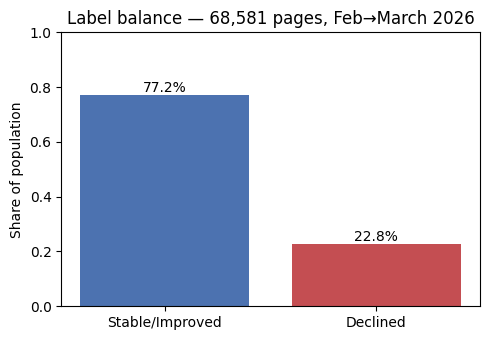

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("work/figures", exist_ok=True)

labels = ["Stable/Improved", "Declined"]
values = [1 - DECLINE_RATE, DECLINE_RATE]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(labels, values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Share of population")
ax.set_title(f"Label balance — {POPULATION_ROWS:,} pages, Feb→March 2026")
for i, v in enumerate(values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("work/figures/label_balance.png", dpi=150)
plt.show()

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Assumptions, features, label definition, baseline, validation design, leakage checks.

### Label definition

`declined_flag` = 1 if `impressions_march < impressions_feb`, else 0 — a same-window
comparison, not a future-window outcome. This is a real limitation, stated honestly:
the model tests "can I detect concurrent decline from surrounding signals," not
"can I predict decline before it happens." Base rate: 22.8% declined (68,581 rows).

### Population and volume floor

Content items in both `fact_feb` and `fact_march`, `gsc_data_available = TRUE`,
filtered to `impressions_march >= 250`. This floor was validated, not assumed: pages
below 250 impressions declined at 36.2% (n=65,657) vs. 22.8% for pages above it
(n=68,581) — low-volume pages show a 13.4-point inflated decline rate, consistent
with noise rather than real demand change (w04 Signal Audit, Signal 2, verdict
CONFIRMED).

### Baseline (w04)

Score = raw percent decline (Feb→March), ranked descending, restricted to the
250-impression floor. Reviewed by hand, top 20 — and this review surfaced a real
weakness worth stating up front: 19 of the top 20 baseline picks were dominated by
pages with a *recent content edit* inside or near the comparison window, not neglect.
Only 1 of 20 was an uncontaminated refresh candidate. This is why "biggest raw drop"
alone is not a trustworthy rule, and why the final playbook (Section 6) requires 2+
independent reason codes per row rather than ranking on decline magnitude alone.

### Features (final model, w05/w06)

**Numeric (16):** keyword_char_count, keyword_token_count, url_char_count,
search_volume, competition, cpc, backlinks, category_count, char_count, word_count,
impressions_jan, clicks_jan, avg_position_jan, days_with_impressions_jan,
impressions_volatility_jan, ctr_jan — with rare-category bucketing and
log-transformation applied to the heaviest-skewed columns (search_volume skew 56.0,
backlinks skew 107.4, cpc skew 15.2 before transform).

**Categorical:** content_type, competition_level, main_intent, provider_used,
model_used, plus tiered buckets (age, freshness, word-count, impression, position).

**January behavioral features** were added deliberately as a Week 5 improvement,
strictly before the Feb–March label window (no window overlap). 13,968 of 68,581
rows (20.4%) have no January history; these are imputed via median, then explicitly
blocked from Critical priority downstream (Section 6) rather than trusted at face
value.

### Method

Logistic regression, `class_weight='balanced'`. Simple and explainable was the
deliberate choice over a tree ensemble — a coefficient table is auditable by a
non-ML reviewer, which matters for a decision-support tool a human has to trust.

### Validation design — and why a naive split would have lied

`StratifiedGroupKFold`, grouped by `client_hash_id`, 3 folds. This was not the
default choice — it was forced by a direct test: a single random split's test-set
decline rate swung from 3.8% to 30.0% across 5 seeds, purely from which of 34 clients
(top 4 holding ~67% of rows) landed in the test fold. A naive random 80/20 split
measured **AUC 0.692** (mean of 5 seeds, std 0.003). The same model under
client-grouped holdout measured **AUC 0.576–0.594** (mean of 5 seeds, std 0.034; 3-fold
cross-val mean 0.594, range 0.538–0.629). That ~0.12 AUC gap is attributable to
client-level leakage — the model partly memorizing per-client patterns rather than
learning generalizable signal — not to feature strength.

### Leakage checks performed (w03, w06)

1. **Label-derived columns** — `trend_direction`, `trend_pct`, `is_declining_label`
   excluded; same fact as the target in three formats.
2. **Forward-looking dates** — `optimization_eligible_date`, `last_optimized_date`
   excluded (temporal leakage; not knowable at decision time).
3. **Hash IDs** — used for grouping/joins only, confirmed absent from the feature
   matrix.
4. **Direct leakage trap (w03 demonstration):** adding a label-derivative feature
   pushed AUC from 0.590 (honest) to 1.000 (leaked) — a controlled proof of what
   circular leakage looks like, kept in the record as evidence the audit was real,
   not assumed.
5. **Snapshot-timing fields** (`is_published`, `is_deleted`) — checked for
   correlation with the label; near-identical rates across classes (0.999 vs 0.999
   published; 0.0001 vs 0.0007 deleted) — confirmed clean.
6. **Static-metadata-only comparison:** a model using only content metadata
   (no behavioral features) scored AUC ≈ 0.533 — near chance. This is a genuine
   negative finding, not a failure to fix: static page attributes alone do not
   predict month-over-month decline without behavioral history.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Carried forward from w03/w05/w06 — not recomputed here.
NAIVE_AUC_MEAN, NAIVE_AUC_STD = 0.692, 0.003
GROUPED_AUC_MEAN, GROUPED_AUC_STD = 0.594, None  # 3-fold CV mean, range 0.538-0.629
GROUPED_AUC_5SEED_MEAN, GROUPED_AUC_5SEED_STD = 0.576, 0.034
STATIC_ONLY_AUC = 0.533
LEAKAGE_TRAP_HONEST_AUC, LEAKAGE_TRAP_LEAKED_AUC = 0.590, 1.000

print(f"Naive split:        {NAIVE_AUC_MEAN} (±{NAIVE_AUC_STD})")
print(f"Grouped (3-fold):   {GROUPED_AUC_MEAN}")
print(f"Grouped (5-seed):   {GROUPED_AUC_5SEED_MEAN} (±{GROUPED_AUC_5SEED_STD})")
print(f"Static-only:        {STATIC_ONLY_AUC}")
print(f"Leakage trap:       {LEAKAGE_TRAP_HONEST_AUC} → {LEAKAGE_TRAP_LEAKED_AUC}")

Naive split:        0.692 (±0.003)
Grouped (3-fold):   0.594
Grouped (5-seed):   0.576 (±0.034)
Static-only:        0.533
Leakage trap:       0.59 → 1.0


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Model vs baseline on the same split. The honest table.

### The comparison (3-fold StratifiedGroupKFold, grouped by client)

| Fold | Test rows | Model P@50 | Baseline P@50 | Model AUC | Model AP |
|------|-----------|------------|----------------|-----------|----------|
| 0    | 9,475     | 0.20       | 0.10           | 0.615     | 0.147    |
| 1    | 45,705    | 0.34       | 0.42           | 0.629     | 0.350    |
| 2    | 13,401    | 0.18       | 0.18           | 0.538     | 0.188    |
| **Mean** | —     | **0.240**  | **0.233**      | **0.594** | **0.228**|

Base rate (random-chance precision): **22.8%** decline rate across the full
population.

### What this table actually shows

**AUC:** the model separates decliners from non-decliners meaningfully better than
chance (0.594 mean, range 0.538–0.629 across folds) — but this is well below the
naive-split number (0.692), and that gap is the honest number, not the 0.692.

**P@50 (top-50 review precision):** the model's mean (0.240) barely beats the
baseline's mean (0.233) — and both are barely above the 22.8% random-chance base
rate. Fold 1 is the clearest case: the baseline *outperformed* the model at P@50
(0.42 vs 0.34) despite the model's higher AUC. This is not a contradiction to
paper over — AUC measures ranking quality across the whole distribution, while
P@50 measures only the very top of a specific fold, and fold sizes here are
uneven (9,475 vs 45,705 vs 13,401 rows) and drawn from as few as 6–12 clients per
fold, so top-50 precision is noisy at this scale.

**Honest verdict:** the model shows real, measured discrimination ability the
baseline rule doesn't have (AUC), but that has not yet translated into a clearly
better top-K review queue (P@50) under honest client-grouped validation. The
model's advantage is a foundation to build on, not a finished win — which is why
Section 6's queue leans on multiple reason codes per row rather than trusting the
model score alone.

### A number that is NOT from this work

The starter repo (`notebooks/`, not `work/`) reports its own benchmark on a
different, smaller slice (30,000-row anonymized starter dataset, not the 68,581-row
warehouse population used here): baseline rules AUC 0.627, random forest AUC 0.750.
Those numbers belong to the starter repo's own pipeline and are **not** a result of
this capstone's analysis — they're noted here only so the comparison table above
isn't mistaken for an improvement on them.

In [2]:
import os
os.makedirs("work/figures", exist_ok=True)

   fold  test_rows  model_p50  baseline_p50  model_auc  model_ap
0     0       9475       0.20          0.10      0.615     0.147
1     1      45705       0.34          0.42      0.629     0.350
2     2      13401       0.18          0.18      0.538     0.188

Means:
model_p50       0.240000
baseline_p50    0.233333
model_auc       0.594000
model_ap        0.228333
dtype: float64


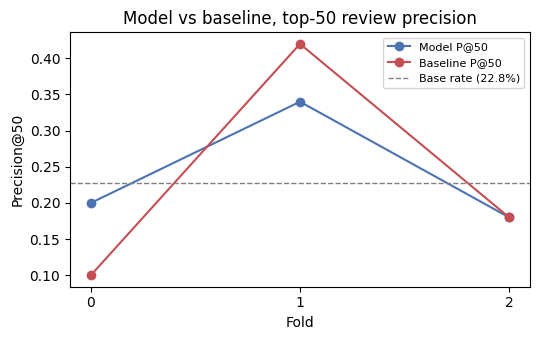

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "fold": [0, 1, 2],
    "test_rows": [9475, 45705, 13401],
    "model_p50": [0.20, 0.34, 0.18],
    "baseline_p50": [0.10, 0.42, 0.18],
    "model_auc": [0.615, 0.629, 0.538],
    "model_ap": [0.147, 0.350, 0.188],
})
print(results)
print("\nMeans:")
print(results[["model_p50", "baseline_p50", "model_auc", "model_ap"]].mean())

fig, ax = plt.subplots(figsize=(5.5, 3.5))
x = results["fold"]
ax.plot(x, results["model_p50"], marker="o", label="Model P@50", color="#4C72B0")
ax.plot(x, results["baseline_p50"], marker="o", label="Baseline P@50", color="#C44E52")
ax.axhline(0.228, linestyle="--", color="gray", linewidth=1, label="Base rate (22.8%)")
ax.set_xticks(x)
ax.set_xlabel("Fold")
ax.set_ylabel("Precision@50")
ax.set_title("Model vs baseline, top-50 review precision")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline_p50.png", dpi=150)
plt.show()

## 5. Limitations

*What this work cannot claim.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.